In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
from matplotlib import pyplot as plt
from src.post_process_functions import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
#load data (model)
res_savename_ext = "post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225"
#"post_processed_new_unit_std_labelled_reports_turnoff_subtype_val_meta-llama_llama-4-scout-17b-16e-instruct_v131025"
#"post_processed_flags_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
#"test_new_flags_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v230925"
#"post_processed_flags_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
#"post_processed_flags_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v230925"
extracted_df = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))

#load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_all_v111025"
labelled_df = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))

#split_lowest = False
#suffix = "_geo_split_lowest" if split_lowest else "_geo"
#suffix+="_v250925"
##load geocoded data
#extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+".gpkg"))
#
##load data (labelled)
#labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix+".gpkg"))
#
##load matched data
#filename_out = f"matched_data_labelled_extracted_row_matching_v120925"
#matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_out + ".feather")#)

In [3]:
#reformat output
from re import match


num_cols = ["impactValue"]#, "geocoding_osm_flag", "geocoding_country_flag"]#"startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"
list_cols_ext = ["country", "location", "hazards", "valueAnnotation", "locationAnnotation", "dateAnnotation", "hazardsAnnotation"]
list_cols_lab = ["country", "location", "hazards", "annotation"]
labelled_df = format_output(labelled_df, num_cols=num_cols, list_cols=list_cols_lab)
extracted_df = format_output(extracted_df, num_cols=num_cols, list_cols=list_cols_ext)
#DEF_CRS_EPSG = "EPSG:4326"
#labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)
#matched_df = matched_df.set_crs(DEF_CRS_EPSG, allow_override=True)

In [4]:
flag_cols = [label for label in extracted_df.columns if "flag_" in label or "valid_errors_" in label]

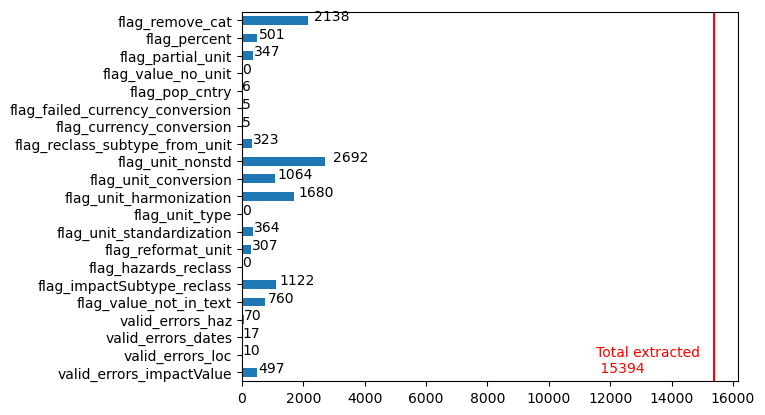

In [5]:
ax = extracted_df[flag_cols].sum().plot(kind="barh")
ax.axvline(len(extracted_df), color="red")
ax.text(len(extracted_df)*0.75, 0, f"Total extracted\n {len(extracted_df)}", color="red")
for i, v in enumerate(extracted_df[flag_cols].sum()):
    ax.text(v*1.1, i, f"{v}", color="black")
#extracted_df[["appealCode"]+ flag_cols].plot(kind="barh")

In [11]:
extracted_df[extracted_df["flag_unit_nonstd"]==True]["impactUnit"].value_counts()

impactUnit
chf                        778
%                          190
km**2                      114
%ent                        59
usd                         45
                          ... 
power stations               1
pipe water points            1
anganwadi centers            1
electrical sub-stations      1
metric kg                    1
Name: count, Length: 726, dtype: int64

In [12]:
extracted_df[extracted_df["flag_unit_harmonization"]==True]["impactUnit"].value_counts()

impactUnit
people                              681
homes                               574
roads                                94
% of people                          84
%ent                                 59
                                   ... 
drinking water supply structures      1
people water structures               1
wash structures                       1
other damaged structures              1
%ent of digicel coverage network      1
Name: count, Length: 64, dtype: int64

In [17]:
extracted_df[extracted_df["impactUnit"]=="squarekm**2"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,flag_unit_conversion,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_currency_conversion,flag_failed_currency_conversion,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent,flag_remove_cat
1817,Water Quality and Availability,4.580000,NaN,NaN,exact,squarekm**2,[Botswana had approximately 4.58 square kilome...,0,[Botswana],[],...,False,True,False,False,False,NaN,False,False,False,False
5806,Crop Production and Forestry,1000.000000,NaN,NaN,exact,squarekm**2,"[• 1,000 square kilometres of area under agric...",0,[India],[Odisha],...,False,True,False,False,False,NaN,False,False,False,False
5833,Residential Buildings,1000.000000,NaN,NaN,exact,squarekm**2,"[1,000 square kilometres of agricultural land ...",0,[India],[Odisha],...,False,True,False,False,False,NaN,False,False,False,False
9585,Crop Production and Forestry,6.490307,NaN,NaN,exact,squarekm**2,"[Over 6,490,307 square metres (649.0307 hectar...",0,[Nigeria],[],...,False,True,False,False,False,NaN,False,False,False,False


In [15]:
extracted_df[extracted_df["flag_unit_conversion"]==True][["impactUnit", "impactValue"]]

,impactUnit,impactValue
14,people,2880.0
119,people,10500.0
134,people,2481.0
146,people,189.0
161,people,954.0
...,...,...
15312,people,1500.0
15338,people,1200.0
15351,people,525.0
15365,people,813.0


In [13]:
extracted_df[extracted_df["impactUnit"]== "people latrines"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,flag_unit_conversion,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_currency_conversion,flag_failed_currency_conversion,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent,flag_remove_cat
978,"Water, Sanitation, and Hygiene Infrastructure",1800.0,NaN,NaN,exact,people latrines,[Construction of 600 household latrines with s...,0,[Bangladesh],"[Jamalpur district, Sapdhori Union of Islampur...",...,True,True,False,False,False,NaN,False,False,False,False
2051,"Water, Sanitation, and Hygiene Infrastructure",600.0,NaN,NaN,exact,people latrines,[Four wells (out of seven) in Gemena town were...,0,[Democratic Republic of the Congo],[Gemena],...,True,True,False,False,False,NaN,False,False,False,False
2362,"Water, Sanitation, and Hygiene Infrastructure",7251.0,NaN,NaN,exact,people latrines,"[Some 2417 family latrines were damaged, 1092 ...",0,[Central African Republic],"[Bangui, Arrondissement 2, Arrondissement 3, A...",...,True,True,False,False,False,NaN,False,False,False,False
2380,"Water, Sanitation, and Hygiene Infrastructure",78.0,NaN,NaN,exact,people latrines,"[In total, 12 community wells and 26 family la...",0,[Central African Republic],"[Bria, Haute-Kotto Prefecture]",...,True,True,False,False,False,NaN,False,False,False,False
7553,"Water, Sanitation, and Hygiene Infrastructure",243.0,NaN,NaN,exact,people latrines,[In Qacha’s Nek (Sehaba Theebe) 81 family latr...,0,[Lesotho],"[Qacha’s Nek, Sehaba Theebe]",...,True,True,False,False,False,NaN,False,False,False,False
11884,"Water, Sanitation, and Hygiene Infrastructure",717.0,NaN,NaN,exact,people latrines,[Table 1: Impact of 7- 9 May disaster ... 239],0,[Rwanda],"[Gakenke, Ngororero, Nyabihu, Rubavu]",...,True,True,False,False,False,NaN,False,False,False,False
11897,"Water, Sanitation, and Hygiene Infrastructure",201.0,NaN,NaN,exact,people latrines,[Table 1: Impact of 7- 9 May disaster ... 67],0,[Rwanda],[Ngororero],...,True,True,False,False,False,NaN,False,False,False,False
12261,"Water, Sanitation, and Hygiene Infrastructure",120.0,NaN,NaN,exact,people latrines,[rehabilitation/construction of 40 household l...,0,[Senegal],"[Dakar, Thiès]",...,True,True,False,False,False,NaN,False,False,False,False


In [43]:
extracted_df[extracted_df["impactUnit"] == "unknown"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,unit_type,flag_unit_type,flag_unit_harmonization,flag_unit_conversion,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent
373,Other Infrastructural Impacts,74.0,NaN,NaN,exact,unknown,[Landslides 74],0,[El Salvador],[],...,other,False,False,False,True,False,NaN,False,False,False
374,Other Infrastructural Impacts,7.0,NaN,NaN,exact,unknown,[Overflowed rivers 7],0,[El Salvador],[],...,other,False,False,False,True,False,NaN,False,False,False
375,Other Infrastructural Impacts,1.0,NaN,NaN,exact,unknown,[Subsidences 1],0,[El Salvador],[],...,other,False,False,False,True,False,NaN,False,False,False
435,Other Human Impacts,50.0,NaN,NaN,exact,unknown,[From 130 to 50 training sessions in hygiene p...,0,[Guatemala],"[El Quiché, Western Temperate Highlands]",...,other,False,False,False,True,False,NaN,False,False,False
436,Other Human Impacts,12.0,NaN,NaN,exact,unknown,[Operation timeframe: 12 months (ends 4 Januar...,0,[Guatemala],"[El Quiché, Western Temperate Highlands, Guate...",...,other,False,False,False,True,False,NaN,False,False,False
437,Other Human Impacts,3.0,NaN,NaN,exact,unknown,[Operation start date: 3 February 2016],0,[Guatemala],"[El Quiché, Western Temperate Highlands, Guate...",...,other,False,False,False,True,False,NaN,False,False,False
438,Other Human Impacts,4.0,NaN,NaN,exact,unknown,[Operation timeframe: 12 months (ends 4 Januar...,0,[Guatemala],"[El Quiché, Western Temperate Highlands, Guate...",...,other,False,False,False,True,False,NaN,False,False,False
439,Other Human Impacts,11.0,NaN,NaN,exact,unknown,[Date of issue: 11 November 2016],0,[Guatemala],"[El Quiché, Western Temperate Highlands, Guate...",...,other,False,False,False,True,False,NaN,False,False,False
441,Other Human Impacts,28.0,NaN,NaN,exact,unknown,[Actions started on 28 March 2016],0,[Guatemala],"[El Quiché, Western Temperate Highlands, Guate...",...,other,False,False,False,True,False,NaN,False,False,False
443,Other Human Impacts,16.0,NaN,NaN,exact,unknown,[Number of National Societies involved in the ...,0,[Guatemala],"[El Quiché, Western Temperate Highlands, Guate...",...,other,False,False,False,True,False,NaN,False,False,False


In [41]:
extracted_df[extracted_df["unit_type"]=="%"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,unit_type,flag_unit_type,flag_unit_harmonization,flag_unit_conversion,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent
34,Healthcare Infrastructure,80.0,NaN,NaN,exact,% of healthcare structures,[The conflict disrupted the operations of 80% ...,0,[Sudan],[],...,%,False,True,False,False,False,NaN,False,False,False
92,Crop Production and Forestry,40.0,NaN,NaN,exact,% of crop production and forestry,[Prices were 40% higher or more compared to la...,0,[Mozambique],[central and northern zones],...,%,False,False,False,True,False,NaN,False,False,False
95,Access to Food,3.0,NaN,NaN,exact,% of people,[Mozambique National Institute of Statistics' ...,0,[Mozambique],"[Tete, Gaza, Manica, Inhambane]",...,%,False,False,False,True,False,NaN,False,False,False
246,Residential Buildings,98.0,NaN,NaN,exact,% of undefined structures,"[In Grenada, 98% of buildings on Carriacou and...",0,[Grenada],"[Carriacou, Petit Martinique]",...,%,False,True,False,False,False,NaN,False,False,False
247,Residential Buildings,90.0,NaN,NaN,exact,% of homes,[Saint Vincent and the Grenadines experienced ...,0,[Saint Vincent and the Grenadines],[Union Island],...,%,False,False,False,False,False,NaN,False,False,False
299,Other Human Impacts,76.6,NaN,NaN,exact,% of unknown,[Reliance on rainfed agriculture drives the hi...,0,[Zambia],[Rural Zambia],...,%,False,False,False,True,False,NaN,False,False,False
304,Other Human Impacts,40.0,NaN,NaN,exact,% of unknown,[It is believed that the Northern part of Zamb...,0,[Zambia],[Northern part of Zambia],...,%,False,False,False,True,False,NaN,False,False,False
450,Other Human Impacts,13.0,NaN,NaN,exact,% of unknown,"[Appeal Coverage to date: 13 % (269,543 CHF)]",0,[Guatemala],"[El Quiché, Western Temperate Highlands]",...,%,False,False,False,True,False,NaN,False,False,False


In [38]:
extracted_df["impactUnit"].value_counts()

impactUnit
people                                        125
homes                                          29
EUR                                            15
unknown                                        13
km**2 of crop production and forestry          12
affected animals                                8
roads                                           8
WASH structures                                 6
education structures                            4
transportation structures                       3
healthcare structures                           3
% of unknown                                    3
crop production and forestry                    2
undefined structures                            2
businesses                                      2
% of healthcare structures                      1
informal settlements                            1
km**2 of undefined agricultural structures      1
% of homes                                      1
% of undefined structures              

In [42]:
extracted_df[extracted_df["flag_unit_nonstd"]==True]["impactUnit"].value_counts()

impactUnit
%                                              6
percent                                        6
km**2                                          4
children                                       2
 cases                                         1
idp sites                                      1
buildings                                      1
other buildings destroyed (collapsed walls)    1
landslides                                     1
vehicles                                       1
unions                                         1
sub-districts                                  1
districts                                      1
cases                                          1
provinces                                      1
small businesses                               1
vessels                                        1
% of buildings                                 1
water sources                                  1
women                                          1
plants   

In [43]:
extracted_df[~pd.isna(extracted_df["impactValue"]) & pd.isna(extracted_df["impactUnit"])]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,flag_unit_standardization,flag_unit_conversion,unit_type,flag_unit_type,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent
351,Human Deaths,3.0,NaN,NaN,exact,NaN,[Three (3) deaths were also reported and800 pe...,[Guinea Bissau],[None],[Three (3) deaths were also reported and800 pe...,...,False,False,other,False,True,False,NaN,False,False,False
390,Residential Buildings,750.0,NaN,NaN,exact,NaN,[It was reported by the National Directorate G...,[Hungary],[Szabolcs-Szatmár-Bereg County],"[On21 June2016, heavy rain and hailstorm hit S...",...,False,False,other,False,True,False,NaN,False,False,False


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_99603/3303138969.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_flags)  # tab20 has 20 distinct colors


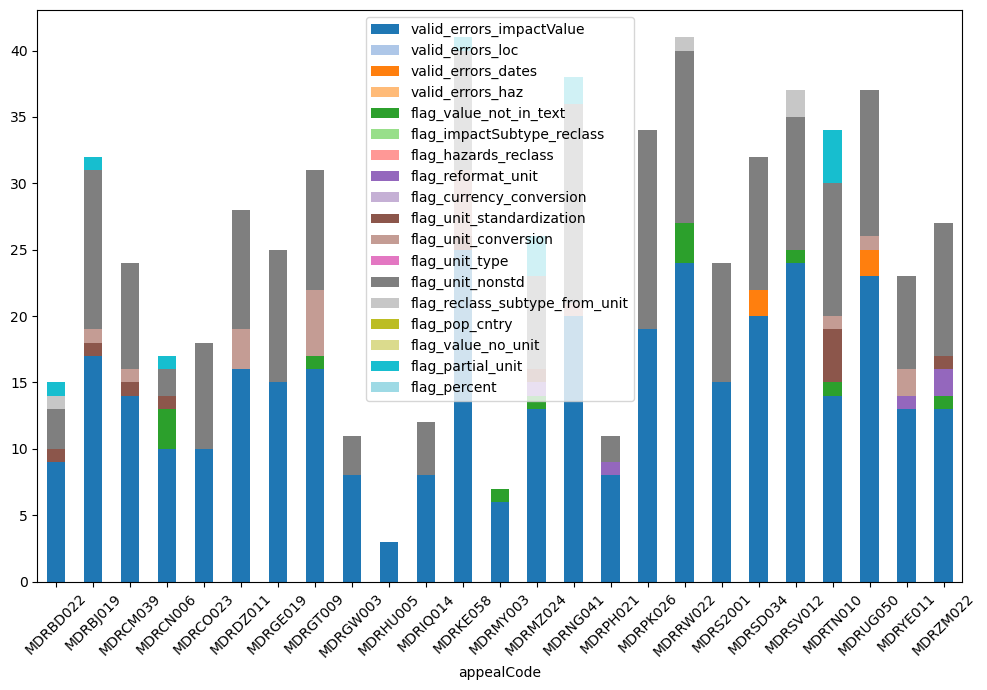

In [23]:
from fileinput import filename
import matplotlib.cm as cm
# Number of unique flag columns
num_flags = len(flag_cols)

# Generate N unique colors from a colormap (e.g., 'tab20', 'viridis', 'nipy_spectral', etc.)
cmap = cm.get_cmap('tab20', num_flags)  # tab20 has 20 distinct colors
colors = [cmap(i) for i in range(num_flags)]

# Make the plot
fig, ax = plt.subplots(1,1, figsize=(10, 7))
extracted_df.groupby("appealCode")[flag_cols].sum().plot(
    kind="bar",
    ax=ax,
    rot=45,
    stacked=True,
    color=colors  # assign unique colors
)

plt.tight_layout()
fig.savefig(DATA_FIGURE / f"flags_{res_savename_ext}.png", bbox_inches="tight", dpi=300)

In [45]:
extracted_df.groupby("appealCode")[flag_cols].sum()

,flag_value_not_in_text,flag_impactSubtype_reclass,flag_hazards_reclass,flag_reformat_unit,flag_currency_conversion,flag_unit_standardization,flag_unit_conversion,flag_unit_type,flag_unit_nonstd,flag_reclass_subtype_from_unit,flag_pop_cntry,flag_value_no_unit,flag_partial_unit,flag_percent
appealCode,,,,,,,,,,,,,,
MDRBD022,0,0,0,0,0,1,1,0,7,1,0,0,0,0
MDRBJ019,0,0,0,0,0,2,0,0,10,0,0,0,2,0
MDRCM039,0,0,0,0,0,1,0,0,8,0,0,0,0,0
MDRCN006,0,0,0,0,0,1,0,0,1,0,0,0,1,0
MDRCO023,0,0,0,0,0,0,0,0,10,0,0,0,0,0
MDRDZ011,0,0,0,0,0,0,3,0,11,0,0,0,0,0
MDRGE019,0,0,0,0,0,0,0,0,13,0,0,0,0,0
MDRGT009,0,0,0,0,0,0,5,0,3,0,0,0,1,0
MDRGW003,0,0,0,0,0,0,1,0,1,0,0,0,0,0


In [46]:
extracted_df[extracted_df["appealCode"] == "MDRSD034"][["hazards", "flag_hazards_reclass"]]

,hazards,flag_hazards_reclass
24,"[Flood, Epidemic, Conflict]",False
25,"[Flood, Epidemic]",False
26,[Flood],False
27,"[Flood, Epidemic, Conflict]",False
28,"[Flood, Epidemic, Conflict]",False
29,"[Flood, Epidemic]",False
30,"[Flood, Conflict, Epidemic]",False
31,[Flood],False
32,"[Conflict, Flood, Epidemic]",False
33,[Flood],False
